# Tarea 0 – IELE756

**Team members:** Sofía Fariña, Martina Retamales.

**Región:** IX – La Araucanía.

**Date:** 12/03/2026  

**Repositorio:** https://github.com/ICI-SofiaFV/iele756-region-IX


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Notebook listo para comenzar")
print("pandas version:", pd.__version__)

Notebook listo para comenzar
pandas version: 2.2.2


## Part 1: Census 2024

In [46]:
# Load selected columns from the Census 2024 persons table
persona = pd.read_parquet("/content/personas_censo2024.parquet",
                          columns=[
        "region", "comuna", "sexo", "edad",
        "p27_nacionalidad", "p27_nacionalidad_rec",
        "escolaridad", "sit_fuerza_trabajo"])

In [47]:
# Check size of the national table
persona.shape


(18480432, 8)

how many rows and columns? The full national table contains **18.480.432 rows** and **8 columns**. The Census 2024 dataset contains a very large number of observations representing individuals in Chile.
The table includes information such as region, commune, sex, age, nationality, education level, and labor force status.

In [48]:
# Review variable types
persona.dtypes

,0
region,int32
comuna,int32
sexo,int32
edad,int32
p27_nacionalidad,int32
p27_nacionalidad_rec,int32
escolaridad,int32
sit_fuerza_trabajo,float64


what are the data types? The data types show that the selected variables are mostly numeric and only one float.

In [49]:
# Preview first 10 rows
persona.head(10)

,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


In [50]:
# Check for missing values and data types
persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


any null values? The dataset does not contain explicit null values according to the dataframe structure.
However, the value -99 is used in several variables to represent missing or unknown data.
This is a common practice in large administrative datasets.

In [51]:
# Filter observations for Region IX
my_region = persona[persona["region"] == 9]
print(f"Rows in my region: {len(my_region):,}")

Rows in my region: 1,010,423


In [52]:

# Compute share of foreign-born residents
foreign = my_region["p27_nacionalidad_rec"].value_counts(normalize=True)

print(f"% foreign-born: {foreign.get(2, 0):.1%}")

% foreign-born: 1.5%


### Distribution of nationality

The distribution of `p27_nacionalidad_rec` shows that most residents in Region IX are Chilean.  
A smaller share corresponds to foreign-born residents, while a small number of observations contain missing values coded as `-99`.

Based on the normalized counts, approximately **1.5% of residents in Region IX are foreign-born**.

## Part 2: ENO — Notifiable Diseases

In [53]:
# Load ENO dataset
eno = pd.read_csv("/20241218_base_eno_final.csv",sep=";",encoding="utf-8-sig")
print(f"Total rows: {len(eno):,}")
print(eno.columns.tolist())

/tmp/ipykernel_150/3106825920.py:2: DtypeWarning: Columns (6,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv("/20241218_base_eno_final.csv",sep=";",encoding="utf-8-sig")


Total rows: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


In [54]:
# Filter ENO records for Region IX
eno_region = eno[eno["region"] == "Región de la Araucanía"]
print(f"Rows in my region: {len(eno_region):,}")

Rows in my region: 11,593


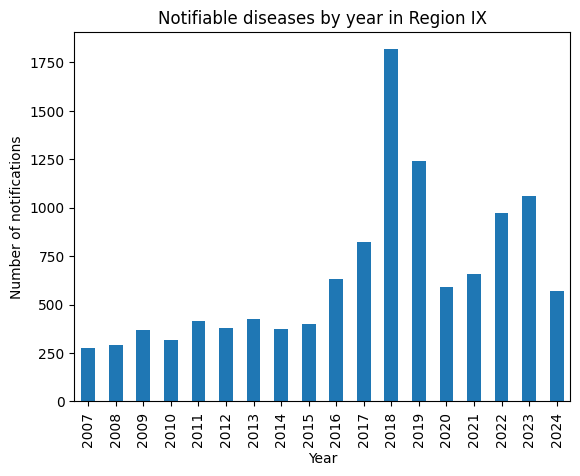

In [55]:
# Count notifications by year
a=eno_region["anho_notificacion"].value_counts().sort_index()
a.plot(kind="bar")
# Plot notifications by year
plt.title("Notifiable diseases by year in Region IX")
plt.xlabel("Year")
plt.ylabel("Number of notifications")
plt.show()

The number of notifications varies across years.
The bar chart illustrates how disease reporting changes over time, which may reflect outbreaks,
changes in surveillance systems, or reporting practices.

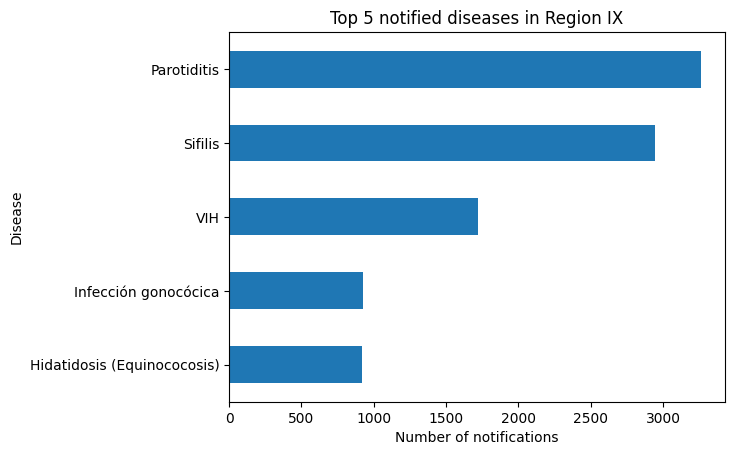

In [56]:
# Identify an plot the top 5 notified diseases
b=eno_region["ENO"].value_counts().head(5)
b.sort_values().plot(kind="barh")

plt.title("Top 5 notified diseases in Region IX")
plt.xlabel("Number of notifications")
plt.ylabel("Disease")
plt.show()

The five most frequently reported diseases represent the most common notifiable conditions in Region IX.
These diseases account for a large share of total notifications.

In [57]:
eno_region["nacionalidad"].value_counts(dropna=False)

,count
nacionalidad,
Chile,5485
Desconocido,5473
Extranjero,635


## Part 3: GRD — Hospital Discharges